In [1]:
# Import necessary libraries
import scanpy as sc
import scipy.cluster.hierarchy as sch
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

## Load scRNA-seq data
adata = sc.read_h5ad("/fs/cbsuvlaminck5/workdir/cjl332/scRNAseq_data/tabsap_v2/tabsap_v2.h5ad")
adata = adata[(adata.obs['disease'] == "normal") & (adata.obs['assay'] == "10x 3' v3")]

## cell types

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(scanpy=True, fontsize=8)

# Define the cell types to highlight
highlight_cell_types = ["endothelial cell of lymphatic vessel", "erythroid progenitor cell"]

# Precompute the number of cells in adata
n_cells = len(adata)

# Create a new column in adata.obs to store the color information
adata.obs['highlight'] = 'Other'

# Use a mask to optimize the .loc operation
mask = adata.obs['cell_type'].isin(highlight_cell_types)
adata.obs.loc[mask, 'highlight'] = adata.obs.loc[mask, 'cell_type']

# Update labels for nicer formatting
highlight_labels = {
    'endothelial cell of lymphatic vessel': 'Endothelial cell of\nlymphatic vessel',
    'erythroid progenitor cell': 'Erythroid progenitor'
}
adata.obs['highlight'] = adata.obs['highlight'].replace(highlight_labels)

# Ensure 'highlight' is categorical so Scanpy assigns colors
adata.obs['highlight'] = adata.obs['highlight'].astype('category')

# Define the size for the highlighted cell types
default_size = 12000 / n_cells
highlighted_size = (120000 / n_cells) * 20
adata.obs['size'] = default_size
adata.obs.loc[mask, 'size'] = highlighted_size`

/tmp/ipykernel_3611474/2506692509.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['highlight'] = 'Other'


/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


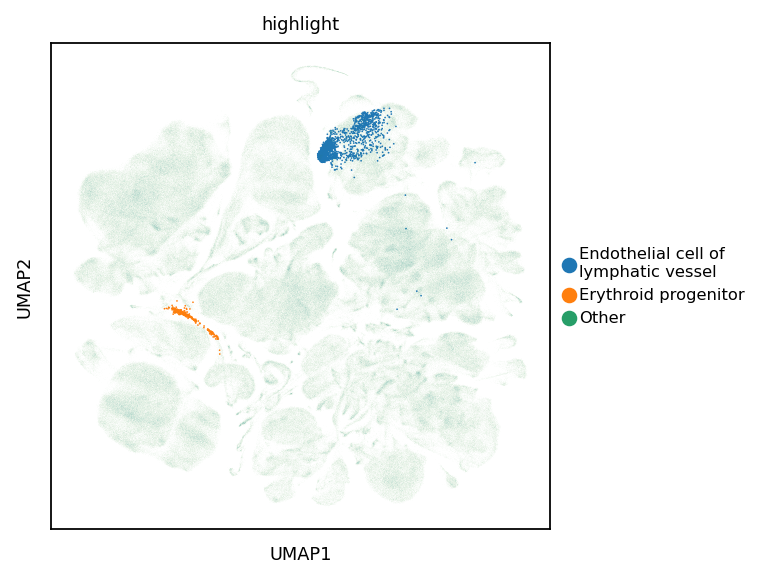

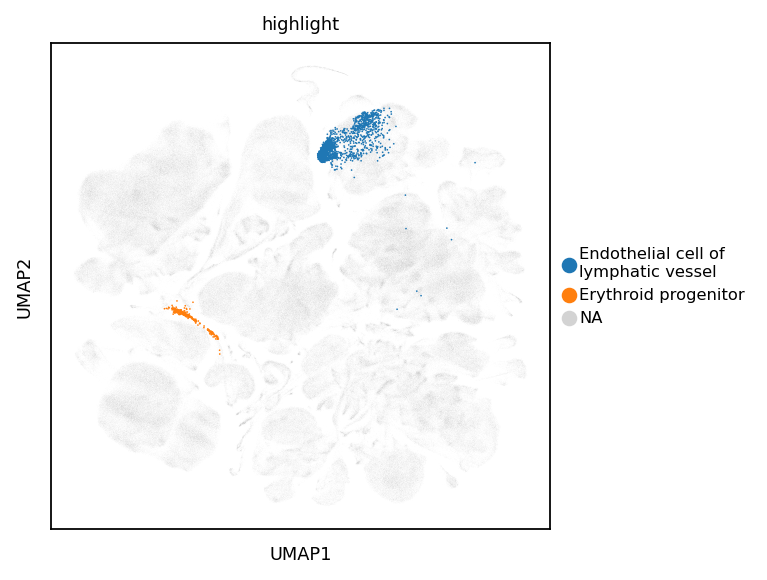

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


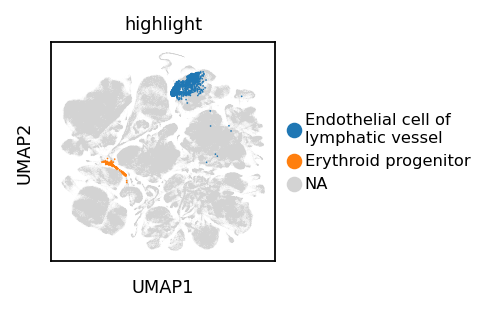

In [3]:
# Plot once to trigger color assignment in adata.uns
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, show=False)

# Now we can safely remove 'Other' from the color list
highlight_colors = adata.uns['highlight_colors']
categories = adata.obs['highlight'].cat.categories
filtered_colors = [color for label, color in zip(categories, highlight_colors) if label != 'Other']
adata.uns['highlight_colors'] = filtered_colors

# Filter categories so 'Other' is not shown in legend
adata.obs['highlight'] = adata.obs['highlight'].cat.remove_categories(['Other'])

# Final plot
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values)

# Save as high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, ax=ax, show=False)
plt.savefig('umap_highlighted_cells.png', dpi=300, bbox_inches='tight')

---
# RHD & CCL21

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/anndata/_core/anndata.py:1295: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(


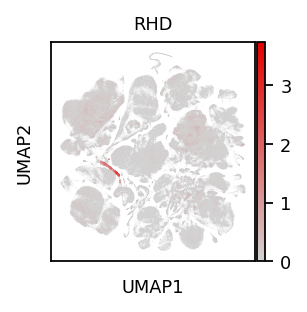

In [ ]:
GENE = "RHD"


# Define the size for the highlighted cell types
adata.obs['size'] = 12000 / len(adata)  # default size
adata.obs.loc[adata.obs['cell_type'].isin(["erythroid progenitor cell"]), 'size'] = (120000 / len(adata)) * 20  # larger size for highlighted cells


sc.set_figure_params(scanpy=True, fontsize=8)

# Save the updated UMAP plot as a high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, 
        color=GENE,
        gene_symbols = "feature_name", 
        layer = "X",
        legend_fontsize = 6,
        size=adata.obs['size'].values, 
        cmap=sns.blend_palette(["lightgray", sns.xkcd_rgb["red"]], as_cmap=True), 
        
        ax=ax, show=False)

plt.xlabel('UMAP1', size = 8)
plt.ylabel('UMAP2', size = 8)

plt.savefig("umap_"+GENE+'.png', dpi=300, bbox_inches='tight')

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/anndata/_core/anndata.py:1295: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(


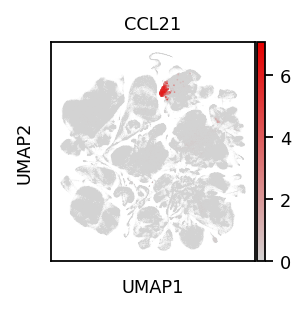

In [118]:
GENE = "CCL21"


# Define the size for the highlighted cell types
adata.obs['size'] = 12000 / len(adata)  # default size
adata.obs.loc[adata.obs['cell_type'].isin(["endothelial cell of lymphatic vessel"]), 'size'] = (120000 / len(adata)) * 20  # larger size for highlighted cells

sc.set_figure_params(scanpy=True, fontsize=8)

# Save the updated UMAP plot as a high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, 
        color=GENE,
        gene_symbols = "feature_name", 
        layer = "X",
        legend_fontsize = 6,
        size=adata.obs['size'].values, 
        cmap=sns.blend_palette(["lightgray", sns.xkcd_rgb["red"]], as_cmap=True), 
        
        ax=ax, show=False)

plt.xlabel('UMAP1', size = 8)
plt.ylabel('UMAP2', size = 8)

plt.savefig("umap_"+GENE+'.png', dpi=300, bbox_inches='tight')

---
# TEMPLATE

In [ ]:
combine = [
"endothelial cell of vascular tree",
"cardiac endothelial cell",
"endothelial cell of artery",
"vein endothelial cell",
"capillary endothelial cel",
"endothelial cell",
"retinal blood vessel endothelial cell",
]

vascular_smoothmuscle = [
"pericyte",
"vascular associated smooth muscle cell"]


vascular_fibroblast = "adventitial fibroblast"
"myofibroblast cell",


other = ["endothelial cell of lymphatic vessel"]


Tissue = "left coronary artery"


vascular_endothelial = [
    "endothelial cell of vascular tree",
    "cardiac endothelial cell",
    "endothelial cell of artery",
    "vein endothelial cell",
    "capillary endothelial cel",
    "endothelial cell",
    "retinal blood vessel endothelial cell"
]

vascular_smoothmuscle = [
"pericyte",
"vascular associated smooth muscle cell"]

In [82]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(scanpy=True, fontsize=8)

# Define the cell types to highlight
vascular_endothelial = [
    "endothelial cell of vascular tree",
    "cardiac endothelial cell",
    "endothelial cell of artery",
    "vein endothelial cell",
    "capillary endothelial cel",
    "endothelial cell",
    "retinal blood vessel endothelial cell"
]

vascular_smoothmuscle = [
"pericyte",
"vascular associated smooth muscle cell"]

vascular_fibroblast = ["alveolar adventitial fibroblast","myofibroblast cell"]

# Precompute the number of cells in adata
n_cells = len(adata)

# Create a new column in adata.obs to store the color information
adata.obs['highlight'] = 'Other'

# Use a mask to optimize the .loc operation
mask1 = adata.obs['cell_type'].isin(vascular_endothelial)
mask2 = adata.obs['cell_type'].isin(vascular_smoothmuscle)
mask3 = adata.obs['cell_type'].isin(vascular_fibroblast)


adata.obs.loc[mask1, 'highlight'] = "vascular endothelial"
adata.obs.loc[mask2, 'highlight'] = "vascular smooth muscle"
adata.obs.loc[mask3, 'highlight'] = "vascular fibroblast"


# Ensure 'highlight' is categorical so Scanpy assigns colors
adata.obs['highlight'] = adata.obs['highlight'].astype('category')

# Define the size for the highlighted cell types
default_size = 12000 / n_cells
highlighted_size = default_size * 5

adata.obs['size'] = default_size
adata.obs.loc[mask1, 'size'] = highlighted_size
adata.obs.loc[mask2, 'size'] = highlighted_size
adata.obs.loc[mask3, 'size'] = highlighted_size

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


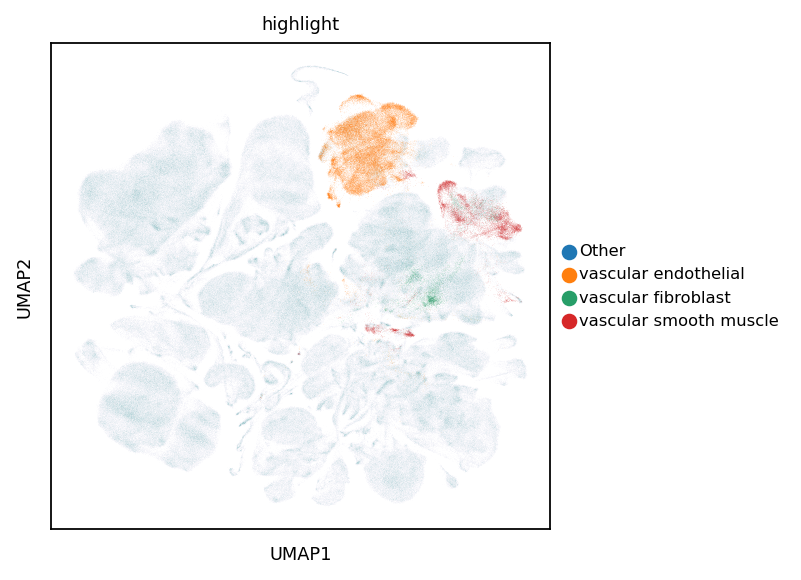

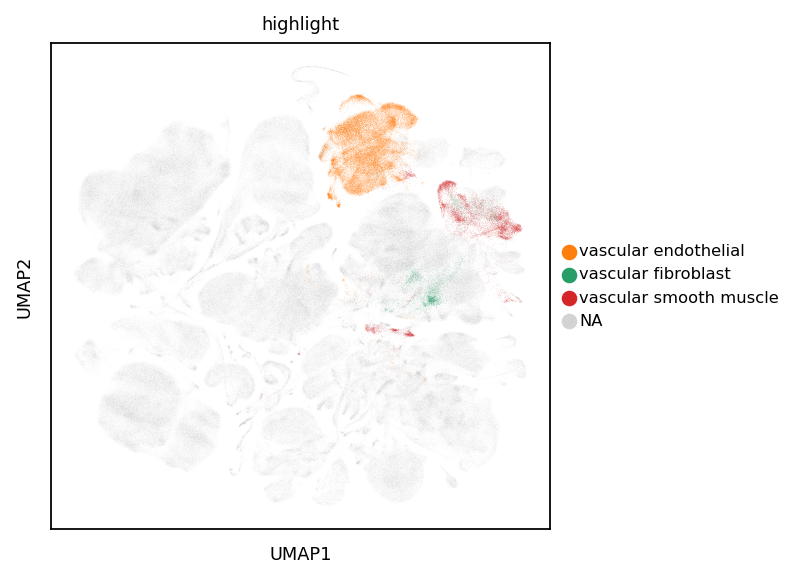

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


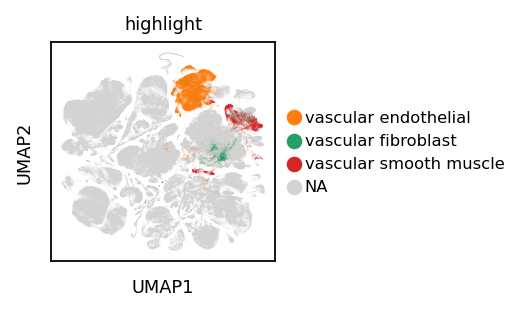

In [83]:
# Plot once to trigger color assignment in adata.uns
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, show=False)

# Now we can safely remove 'Other' from the color list
highlight_colors = adata.uns['highlight_colors']
categories = adata.obs['highlight'].cat.categories
filtered_colors = [color for label, color in zip(categories, highlight_colors) if label != 'Other']
adata.uns['highlight_colors'] = filtered_colors

# Filter categories so 'Other' is not shown in legend
adata.obs['highlight'] = adata.obs['highlight'].cat.remove_categories(['Other'])

# Final plot
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values)

# Save as high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, ax=ax, show=False)
plt.savefig('./A2M/umap_highlighted_cells.png', dpi=300, bbox_inches='tight')

In [84]:
adata.var[adata.var['feature_name'] == "A2M"]

,ensembl_id,genome,mt,ercc,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mean,std,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ensg,,,,,,,,,,,,,,,,
ENSG00000175899,ENSG00000175899.15,Gencode_v41,False,False,381351,25.026616,80.682667,49406019.0,0.336819,0.767744,False,A2M,NCBITaxon:9606,gene,590,protein_coding


/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/anndata/_core/anndata.py:1295: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(


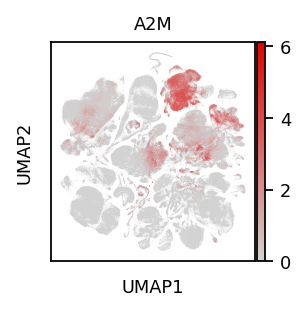

In [85]:
import seaborn as sns

GENE = "A2M"

sc.set_figure_params(scanpy=True, fontsize=8)

# Save the updated UMAP plot as a high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))

sc.pl.umap(adata, 
        color=GENE,
        gene_symbols = "feature_name", 
        layer = "X",
        legend_fontsize = 6,
        size=adata.obs['size'].values, 
        cmap=sns.blend_palette(["lightgray", sns.xkcd_rgb["red"]], as_cmap=True), 
        ax=ax, show=False)

plt.xlabel('UMAP1', size = 8)
plt.ylabel('UMAP2', size = 8)

plt.savefig("./A2M/template_umap_"+GENE+'.png', dpi=300, bbox_inches='tight')

In [53]:
# Get unique values from the 'tissue' column
unique_tissues = adata.obs['tissue'].unique()

# Save the unique values to a file
with open("unique_tissues.txt", "w") as f:
    for tissue in unique_tissues:
        f.write(f"{tissue}\n")

print("Unique tissue values saved to 'unique_tissues.txt'")

Unique tissue values saved to 'unique_tissues.txt'


In [72]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(scanpy=True, fontsize=8)

# Define the cell types to highlight
Tissues = ["coronary artery"]

# Precompute the number of cells in adata
n_cells = len(adata)

# Create a new column in adata.obs to store the color information
adata.obs['highlight'] = 'Other'

# Use a mask to optimize the .loc operation
mask1 = adata.obs['tissue'].isin(Tissues)

adata.obs.loc[mask1, 'highlight'] = "coronary artery"

# Ensure 'highlight' is categorical so Scanpy assigns colors
adata.obs['highlight'] = adata.obs['highlight'].astype('category')

# Define the size for the highlighted cell types
default_size = 12000 / n_cells
highlighted_size = default_size*5

adata.obs['size'] = default_size
adata.obs.loc[mask1, 'size'] = highlighted_size

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


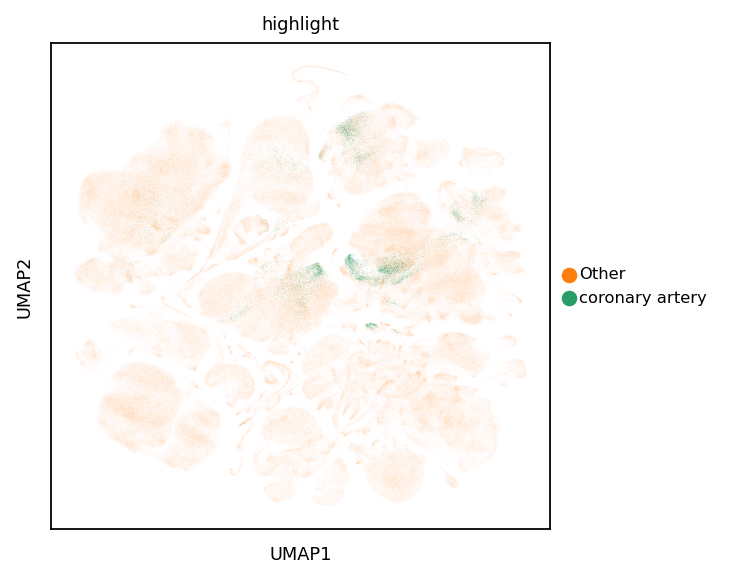

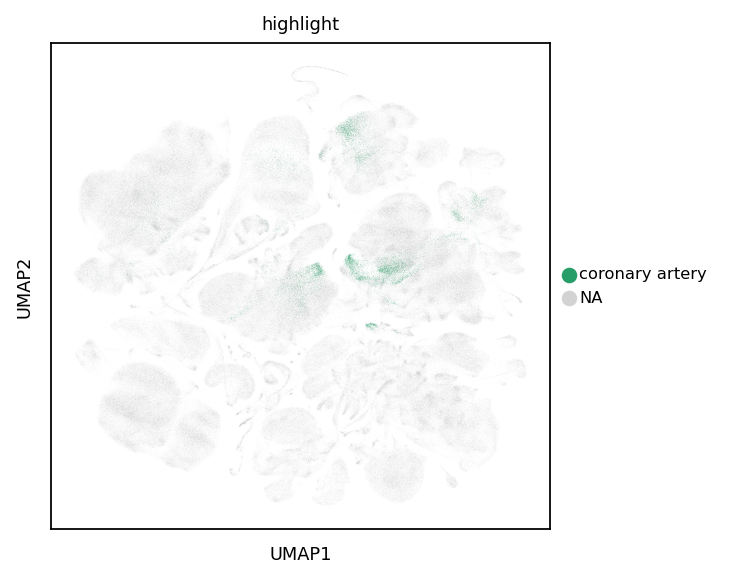

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


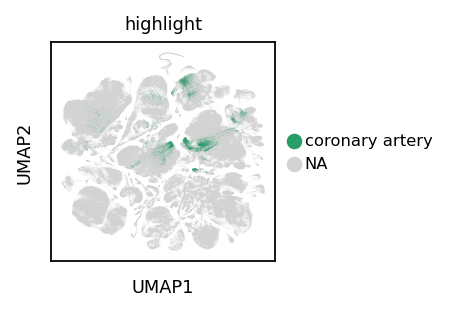

In [73]:
# Plot once to trigger color assignment in adata.uns
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, show=False)

# Now we can safely remove 'Other' from the color list
highlight_colors = adata.uns['highlight_colors']
categories = adata.obs['highlight'].cat.categories
filtered_colors = [color for label, color in zip(categories, highlight_colors) if label != 'Other']
adata.uns['highlight_colors'] = filtered_colors

# Filter categories so 'Other' is not shown in legend
adata.obs['highlight'] = adata.obs['highlight'].cat.remove_categories(['Other'])

# Final plot
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values)

# Save as high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, ax=ax, show=False)
plt.savefig('./A2M/umap_highlighted_tissues.png', dpi=300, bbox_inches='tight')

---
# TMP

In [3]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(scanpy=True, fontsize=8)

# Define the cell types to highlight
highlight_cell_types = ["endothelial cell of lymphatic vessel"]

# Precompute the number of cells in adata
n_cells = len(adata)

# Create a new column in adata.obs to store the color information
adata.obs['highlight'] = 'Other'

# Use a mask to optimize the .loc operation
mask = adata.obs['cell_type'].isin(highlight_cell_types)
adata.obs.loc[mask, 'highlight'] = adata.obs.loc[mask, 'cell_type']

# Update labels for nicer formatting
highlight_labels = {
    'endothelial cell of lymphatic vessel': 'Endothelial cell of\nlymphatic vessel'
}
adata.obs['highlight'] = adata.obs['highlight'].replace(highlight_labels)

# Ensure 'highlight' is categorical so Scanpy assigns colors
adata.obs['highlight'] = adata.obs['highlight'].astype('category')

# Define the size for the highlighted cell types
default_size = 12000 / n_cells
highlighted_size = (120000 / n_cells) * 20
adata.obs['size'] = default_size
adata.obs.loc[mask, 'size'] = highlighted_size

/tmp/ipykernel_1623141/1333847047.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['highlight'] = 'Other'


/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


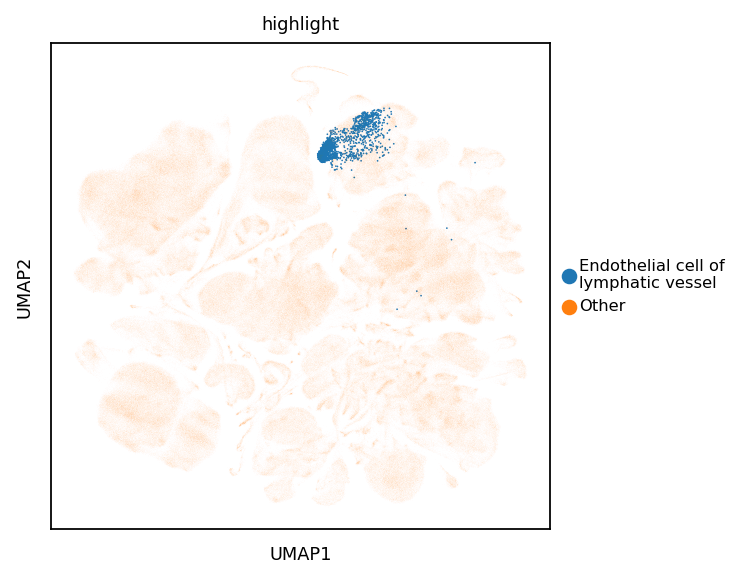

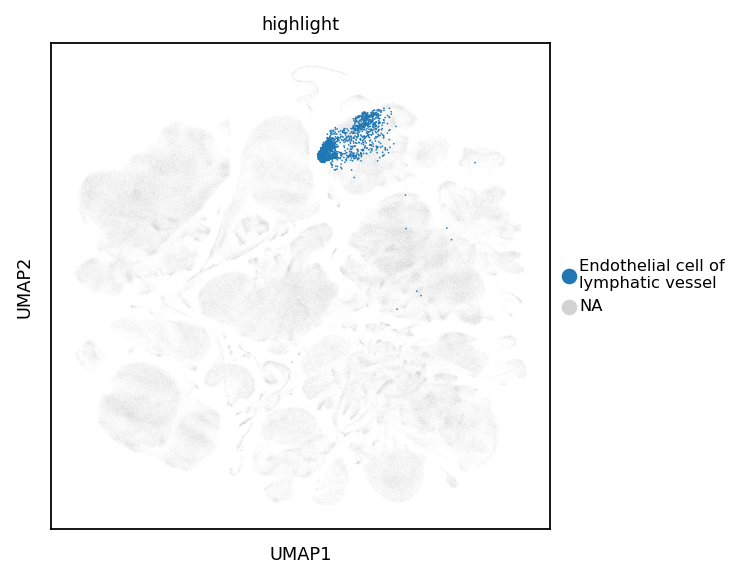

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


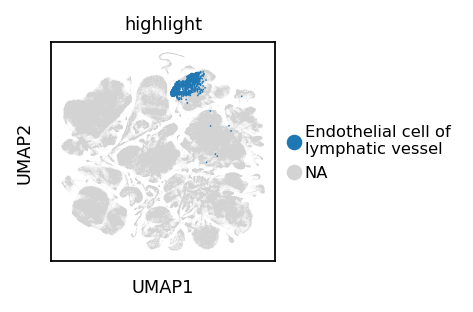

In [4]:
# Plot once to trigger color assignment in adata.uns
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, show=False)

# Now we can safely remove 'Other' from the color list
highlight_colors = adata.uns['highlight_colors']
categories = adata.obs['highlight'].cat.categories
filtered_colors = [color for label, color in zip(categories, highlight_colors) if label != 'Other']
adata.uns['highlight_colors'] = filtered_colors

# Filter categories so 'Other' is not shown in legend
adata.obs['highlight'] = adata.obs['highlight'].cat.remove_categories(['Other'])

# Final plot
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values)

# Save as high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, ax=ax, show=False)
plt.savefig('umap_highlighted_cells.TMP.png', dpi=300, bbox_inches='tight')

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


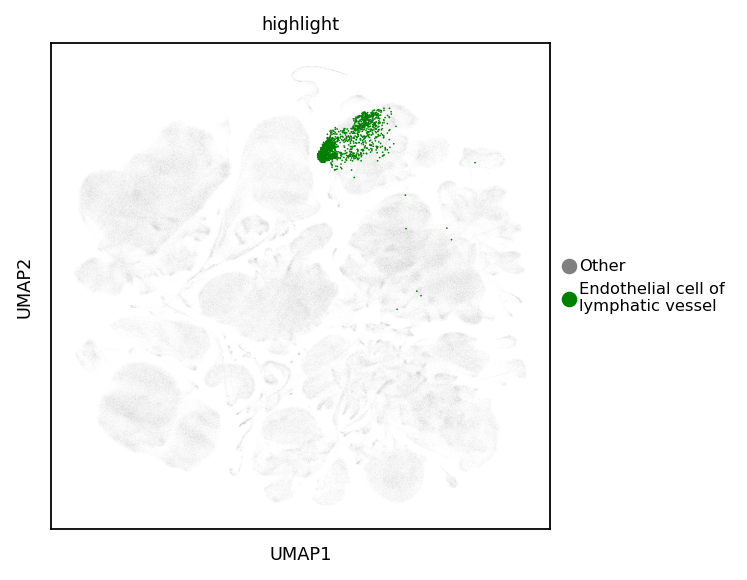

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


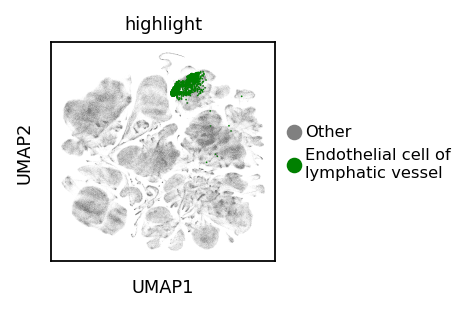

: 

In [ ]:
CELLTYPES = ["endothelial cell of lymphatic vessel"]

sc.set_figure_params(scanpy=True, fontsize=8)

# Define the cell types to highlight
highlight_cell_types = CELLTYPES

# Create a new column in adata.obs to store the color information
adata.obs['highlight'] = 'Other'
adata.obs.loc[adata.obs['cell_type'].isin(highlight_cell_types), 'highlight'] = adata.obs['cell_type']

# Define the size for the highlighted cell types
adata.obs['size'] = 12000 / len(adata)  # default size
adata.obs.loc[adata.obs['cell_type'].isin(highlight_cell_types), 'size'] = (120000 / len(adata)) * 20  # larger size for highlighted cells

# Ensure 'highlight' is a categorical column
adata.obs['highlight'] = adata.obs['highlight'].astype('category')

# Remove "Other" from the legend
# highlight_colors = adata.uns['highlight_colors']
highlight_colors = [color for label, color in zip(adata.obs['highlight'].cat.categories, highlight_colors) if label != 'Other']
adata.uns['highlight_colors'] = highlight_colors

# Update the label for "endothelial cell of lymphatic vessel"
adata.obs['highlight'] = adata.obs['highlight'].replace({'endothelial cell of lymphatic vessel': 'Endothelial cell of\nlymphatic vessel'})
adata.obs['highlight'] = adata.obs['highlight'].replace({'erythroid progenitor cell': 'Erythroid progenitor'})


# Plot the UMAP with updated labels and legend
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, palette=['grey', 'green'])

# Save the updated UMAP plot as a high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, palette=['grey', 'green', 'blue'], ax=ax, show=False)
plt.savefig('template_umap_highlighted_cells.ymp.png', dpi=300, bbox_inches='tight')